# Text-to-Music generation using Riffusion and OpenVINO

[Riffusion](https://huggingface.co/riffusion/riffusion-model-v1) is a latent text-to-image diffusion model capable of generating spectrogram images given any text input. These spectrograms can be converted into audio clips.
General diffusion models are machine learning systems that are trained to denoise random Gaussian noise step by step, to get to a sample of interest, such as an image.
Diffusion models have been shown to achieve state-of-the-art results for generating image data. But one downside of diffusion models is that the reverse denoising process is slow. In addition, these models consume a lot of memory because they operate in pixel space, which becomes unreasonably expensive when generating high-resolution images. Therefore, it is challenging to train these models and also use them for inference. OpenVINO brings capabilities to run model inference on Intel hardware and opens the door to the fantastic world of diffusion models for everyone!

In this tutorial, we consider how to run a text-to-music generation pipeline using Riffusion and OpenVINO. We will use a pre-trained model from the [Diffusers](https://huggingface.co/docs/diffusers/index) library. To simplify the user experience, the [Hugging Face Optimum Intel](https://huggingface.co/docs/optimum/intel/index) library is used to convert the models to OpenVINO™ IR format. For running the spectrogram generation we will use [OpenVINO GenAI](https://github.com/openvinotoolkit/openvino.genai) that provides easy-to-use API.

The tutorial consists of the following steps:

- Install prerequisites
- Download and convert the model from a public source using the [Hugging Face Optimum Intel](https://huggingface.co/docs/optimum/intel/index).
- Create a text-to-music inference pipeline
- Run inference pipeline

## About Riffusion

Riffusion is based on Stable Diffusion v1.5 and fine-tuned on images of spectrogram paired with text. Audio processing happens downstream of the model. This model can generate an audio spectrogram for given input text.

An audio spectrogram is a visual way to represent the frequency content of a sound clip. The x-axis represents time, and the y-axis represents frequency. The color of each pixel gives the amplitude of the audio at the frequency and time given by its row and column.
An audio [spectrogram](https://en.wikipedia.org/wiki/Spectrogram) is a visual way to represent the frequency content of a sound clip. The x-axis represents time, and the y-axis represents frequency. The color of each pixel gives the amplitude of the audio at the frequency and time given by its row and column.

![spectrogram](https://github.com/user-attachments/assets/7cd86e52-02a3-43c6-a296-885fb868f616)


*[*image source](https://www.riffusion.com/about)*

The spectrogram can be computed from audio using the [Short-time Fourier transform (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform), which approximates the audio as a combination of sine waves of varying amplitudes and phases.

![stft.png](https://github.com/user-attachments/assets/5eaa458a-b290-42ad-b7ff-0e09705b7e25)

*[*image source](https://www.riffusion.com/about)*

The STFT is invertible, so the original audio can be reconstructed from a spectrogram. This idea is a behind approach to using Riffusion for audio generation.


#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Stable Diffusion pipeline in Optimum Intel](#Stable-Diffusion-pipeline-in-Optimum-Intel)
    - [Select inference device](#Select-inference-device)
- [Prepare postprocessing for reconstruction audio from spectrogram image](#Prepare-postprocessing-for-reconstruction-audio-from-spectrogram-image)
- [Run Inference pipeline](#Run-Inference-pipeline)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/riffusion-text-to-music/riffusion-text-to-music.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)


In [ ]:
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu Pillow scipy "torch>=2.1" torchaudio "diffusers>=0.16.1" "transformers>=4.33.0"
%pip install -q "git+https://github.com/huggingface/optimum-intel.git" "gradio>=3.34.0"
%pip install -q -U --pre --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly "openvino>=2025.1" "openvino-genai>=2025.1"

## Stable Diffusion pipeline in Optimum Intel
[back to top ⬆️](#Table-of-contents:)

The riffusion model is available for downloading via the [HuggingFace hub](https://huggingface.co/models). We will use optimum-cli interface for exporting it into OpenVINO Intermediate Representation (IR) format.

 Optimum CLI interface for converting models supports export to OpenVINO (supported starting optimum-intel 1.12 version).
General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. Available tasks depend on the model, for riffusion model should be selected `stable-diffusion` as the riffusion model architecture is the same as Stable Diffusion.

You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager).


Full list of supported arguments available via `--help`
For more details and examples of usage, please check [optimum documentation](https://huggingface.co/docs/optimum/intel/inference#export).

When Stable Diffusion models are exported to the OpenVINO format, they are decomposed into three components that consist of four models combined during inference into the pipeline:

* The text encoder
* The U-NET
* The VAE encoder
* The VAE decoder

More details about the Stable Diffusion pipeline can be found in [stable-diffusion](../stable-diffusion-text-to-image/stable-diffusion-text-to-image.ipynb) notebook.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("riffusion-text-to-music.ipynb")

MODEL_ID = "riffusion/riffusion-model-v1"
MODEL_DIR = Path("riffusion_pipeline")

### Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [3]:
from notebook_utils import device_widget

device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [4]:
from cmd_helper import optimum_cli


if not MODEL_DIR.exists():
    optimum_cli(MODEL_ID, MODEL_DIR, additional_args={"weight-format": "fp16"})

We will use [OpenVINO GenAI](https://github.com/openvinotoolkit/openvino.genai) that provides easy-to-use API for running image generation. Firstly we will create pipeline with `Text2ImagePipeline`. You can see more details in [Image Python Generation Pipeline Example](https://github.com/openvinotoolkit/openvino.genai/tree/releases/2025/0/samples/python/image_generation)
Then we just run `generate` method and get the image tokens and then convert them into the image using `Image.fromarray` from PIL.

In [ ]:
import openvino_genai as ov_genai


DEVICE = device.value

pipe = ov_genai.Text2ImagePipeline(MODEL_DIR, DEVICE)

## Prepare postprocessing for reconstruction audio from spectrogram image
[back to top ⬆️](#Table-of-contents:)

The riffusion model generates an audio spectrogram image, which can be used to reconstruct audio. However, the spectrogram images from the model only contain the amplitude of the sine waves and not the phases, because the phases are chaotic and hard to learn. Instead, we can use the [Griffin-Lim](https://ieeexplore.ieee.org/document/1164317) algorithm to approximate the phase when reconstructing the audio clip. The Griffin-Lim Algorithm (GLA) is a phase reconstruction method based on the redundancy of the [Short-time Fourier transform (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform). It promotes the consistency of a spectrogram by iterating two projections, where a spectrogram is said to be consistent when its inter-bin dependency owing to the redundancy of STFT is retained. GLA is based only on consistency and does not take any prior knowledge about the target signal into account. 

The frequency bins in generated spectrogram use the [Mel scale](https://en.wikipedia.org/wiki/Mel_scale), which is a perceptual scale of pitches judged by listeners to be equal in distance from one another.

The code below defines the process of reconstruction of a WAV audio clip from a spectrogram image using Griffin-Lim Algorithm.

In [6]:
import io

import numpy as np
from PIL import Image
from scipy.io import wavfile
import torch
import torchaudio


def wav_bytes_from_spectrogram_image(image: Image.Image) -> tuple[io.BytesIO, float]:
    """
    Reconstruct a WAV audio clip from a spectrogram image. Also returns the duration in seconds.

    Parameters:
      image (Image.Image): generated spectrogram image
    Returns:
      wav_bytes (io.BytesIO): audio signal encoded in wav bytes
      duration_s (float): duration in seconds
    """

    max_volume = 50
    power_for_image = 0.25
    Sxx = spectrogram_from_image(image, max_volume=max_volume, power_for_image=power_for_image)

    sample_rate = 44100  # [Hz]
    clip_duration_ms = 5000  # [ms]

    bins_per_image = 512
    n_mels = 512

    # FFT parameters
    window_duration_ms = 100  # [ms]
    padded_duration_ms = 400  # [ms]
    step_size_ms = 10  # [ms]

    # Derived parameters
    num_samples = int(image.width / float(bins_per_image) * clip_duration_ms) * sample_rate
    n_fft = int(padded_duration_ms / 1000.0 * sample_rate)
    hop_length = int(step_size_ms / 1000.0 * sample_rate)
    win_length = int(window_duration_ms / 1000.0 * sample_rate)

    samples = waveform_from_spectrogram(
        Sxx=Sxx,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        num_samples=num_samples,
        sample_rate=sample_rate,
        mel_scale=True,
        n_mels=n_mels,
        num_griffin_lim_iters=32,
    )

    wav_bytes = io.BytesIO()
    wavfile.write(wav_bytes, sample_rate, samples.astype(np.int16))
    wav_bytes.seek(0)

    duration_s = float(len(samples)) / sample_rate

    return wav_bytes, duration_s


def spectrogram_from_image(image: Image.Image, max_volume: float = 50, power_for_image: float = 0.25) -> np.ndarray:
    """
    Compute a spectrogram magnitude array from a spectrogram image.

    Parameters:
      image (image.Image): input image
      max_volume (float, *optional*, 50): max volume for spectrogram magnitude
      power_for_image (float, *optional*, 0.25): power for reversing power curve
    """
    # Convert to a numpy array of floats
    data = np.array(image).astype(np.float32)

    # Flip Y take a single channel
    data = data[::-1, :, 0]

    # Invert
    data = 255 - data

    # Rescale to max volume
    data = data * max_volume / 255

    # Reverse the power curve
    data = np.power(data, 1 / power_for_image)

    return data


def waveform_from_spectrogram(
    Sxx: np.ndarray,
    n_fft: int,
    hop_length: int,
    win_length: int,
    num_samples: int,
    sample_rate: int,
    mel_scale: bool = True,
    n_mels: int = 512,
    num_griffin_lim_iters: int = 32,
    device: str = "cpu",
) -> np.ndarray:
    """
    Reconstruct a waveform from a spectrogram.
    This is an approximate waveform, using the Griffin-Lim algorithm
    to approximate the phase.
    """
    Sxx_torch = torch.from_numpy(Sxx).to(device)

    if mel_scale:
        mel_inv_scaler = torchaudio.transforms.InverseMelScale(
            n_mels=n_mels,
            sample_rate=sample_rate,
            f_min=0,
            f_max=10000,
            n_stft=n_fft // 2 + 1,
            norm=None,
            mel_scale="htk",
        ).to(device)

        Sxx_torch = mel_inv_scaler(Sxx_torch)

    griffin_lim = torchaudio.transforms.GriffinLim(
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        power=1.0,
        n_iter=num_griffin_lim_iters,
    ).to(device)

    waveform = griffin_lim(Sxx_torch).cpu().numpy()

    return waveform

## Run Inference pipeline
[back to top ⬆️](#Table-of-contents:)

The diagram below briefly describes the workflow of our pipeline

![riffusion_pipeline.png](https://github.com/user-attachments/assets/68439efd-8698-46dd-9998-68bc84c040c6)

As you can see, it is very similar to Stable Diffusion Text-to-Image generation with an additional post-processing step that transforms generated spectrogram into an audio signal. Firstly, `Text2ImagePipeline` accepts input text prompt, which will be tokenized and transformed to embeddings space using Frozen CLIP text encoder and generates initial latent spectrogram representation using a random generator, then U-Net iteratively *denoises* the random latent spectrogram image representations while being conditioned on the text embeddings. The output of the U-Net, being the noise residual, is used to compute a denoised latent image representation via a scheduler algorithm. The *denoising* process is repeated a given number of times (by default 50) to step-by-step retrieve better latent image representations. When complete, the latent image representation is decoded by the decoder part of the variational auto-encoder. Generated spectrogram image tokens will be converted into an image and then into a spectrogram magnitude range and inverse mel scale applied to it to estimate an STFT in the normal frequency domain from the mel frequency domain. Finally, Griffin-Lim Algorithm approximates the phase of an audio signal and we got reconstructed audio. 

In [7]:
def generate(prompt: str, negative_prompt: str = "") -> tuple[Image.Image, str]:
    """
    function for generation audio from text prompt

    Parameters:
      prompt (str): input prompt for generation.
      negative_prompt (str): negative prompt for generation, contains undesired concepts for generation, which should be avoided. Can be empty.
    Returns:
      spec (Image.Image) - generated spectrogram image
    """
    spec_tokens = pipe.generate(prompt, negative_prompt=negative_prompt, num_inference_steps=20)
    spec = Image.fromarray(spec_tokens.data[0])
    wav = wav_bytes_from_spectrogram_image(spec)
    with open("output.wav", "wb") as f:
        f.write(wav[0].getbuffer())
    return spec, "output.wav"

Now, we can test our generation. Function generate accepts text input and returns generated spectrogram and path to generated audio. Optionally, it also accepts negative prompt. A negative prompt declares undesired concepts for generation, e.g. if we want to generate instrumental music, having vocal on audio will be an unwanted effect, so in this case vocal can be treated as a negative prompt. The positive and negative prompts are in equal footing. You can always use one with or without the other. More explanation of how it works can be found in this [article](https://stable-diffusion-art.com/how-negative-prompt-work/). 

In [8]:
spectrogram, wav_path = generate("Techno beat")

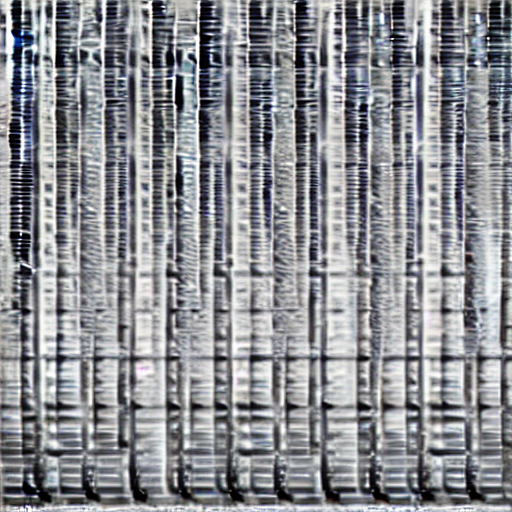

In [9]:
spectrogram

In [10]:
import IPython.display as ipd

ipd.Audio(wav_path)

## Interactive demo
[back to top ⬆️](#Table-of-contents:)


In [11]:
import gradio as gr


def select_device(device_str: str, current_text: str = "", progress: gr.Progress = gr.Progress()):
    """
    Helper function for uploading model on the device.

    Parameters:
      device_str (str): Device name.
      current_text (str): Current content of user instruction field (used only for backup purposes, temporally replacing it on the progress bar during model loading).
      progress (gr.Progress): gradio progress tracker
    Returns:
      current_text
    """
    if device_str != pipe._device:
        pipe.clear_requests()
        pipe.to(device_str)

        for i in progress.tqdm(range(1), desc=f"Model loading on {device_str}"):
            pipe.compile()
    return current_text

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/riffusion-text-to-music/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(generate_fn=generate, select_device_fn=select_device)

try:
    demo.queue().launch(debug=True, height=800)
except Exception:
    demo.queue().launch(debug=True, share=True, height=800)
# If you are launching remotely, specify server_name and server_port
# EXAMPLE: `demo.launch(server_name='your server name', server_port='server port in int')`
# To learn more please refer to the Gradio docs: https://gradio.app/docs/